# Load Dataset

In [1]:
import os
import json
import pandas as pd

dfs = []
for file_path in os.listdir("./data/"):
  if file_path.endswith(".json"):
    with open(file_path, "r", encoding="utf-8") as f:
      print(f"Loading '{file_path}'...")
      data = json.load(f)
      df = pd.DataFrame(data["reviews"])
      df["model"] = data["model"]
      df["total_reviews"] = data["total_reviews"]
      df = df[["model", "restaurant", "category", "rating", "keywords", "gen_review", "word_count", "total_reviews", "human_review"]]
      dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

Loading 'mistral_latest_reviews.json'...
Loading 'qwen3_latest_reviews.json'...
Loading 'deepseek-r1_latest_reviews.json'...
Loading 'llama3.1_latest_reviews.json'...


In [7]:
combined_df.sample(5)

,model,restaurant,category,rating,keywords,gen_review,word_count,total_reviews,human_review
57,qwen3:latest,Club Rogue,General,2.7,"['guess', '25', 'mind']","<think>\nOkay, the user wants me to simulate a...",258,50,overcrowded is the first thing that comes to m...
192,llama3.1:latest,Zing's Northeast Kitchen,Japanese,1.0,"['authentic', 'terrible', 'standards']",I'm thoroughly disappointed with my recent vis...,85,50,terrible food deeply dissatisfied ramen is jus...
159,llama3.1:latest,Hotel Zara Hi-Fi,General,1.2,"['spoiled', 'zomato', 'complete']",I'm extremely disappointed with my experience ...,81,50,worst experience ever and never received such ...
27,mistral:latest,The Foodie Monster Kitchen,General,5.0,"['online', 'customers', 'definitely']",Title: A Monster of a Meal Experience - The Fo...,180,50,good service and good food quality really valu...
33,mistral:latest,Behrouz Biryani,Indian,1.0,"['received', 'order', 'given']",Title: Disappointing Experience at Behrouz Bir...,120,50,not received my order fuck off


In [10]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model          200 non-null    object 
 1   restaurant     200 non-null    object 
 2   category       200 non-null    object 
 3   rating         200 non-null    float64
 4   keywords       200 non-null    object 
 5   gen_review     200 non-null    object 
 6   word_count     200 non-null    int64  
 7   total_reviews  200 non-null    int64  
 8   human_review   200 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 14.2+ KB


In [11]:
combined_df.model.unique()

array(['mistral:latest', 'qwen3:latest', 'deepseek-r1:latest',
       'llama3.1:latest'], dtype=object)

In [12]:
combined_df.model.value_counts()

,count
model,
mistral:latest,50
qwen3:latest,50
deepseek-r1:latest,50
llama3.1:latest,50


In [13]:
combined_df.restaurant.unique()

array(["Domino's Pizza", "3B's - Buddies, Bar & Barbecue",
       'The Foodie Monster Kitchen', 'Behrouz Biryani', 'Deli 9 Bistro',
       'Club Rogue', "Jonathan's Kitchen - Holiday Inn Express & Suites",
       'Arena Eleven', 'Pakwaan Grand', 'La La Land - Bar & Kitchen',
       'Pista House', 'Triptify', 'Beyond Flavours', 'The Indi Grill',
       'Hotel Zara Hi-Fi', 'Hitech Bawarchi Food Zone', 'Momos Delight',
       "Zing's Northeast Kitchen"], dtype=object)

In [14]:
combined_df.category.unique()

array(['Italian', 'Steakhouse', 'General', 'Indian', 'Bar', 'Mexican',
       'Japanese'], dtype=object)

### Clean Generated Review Text

In [16]:
combined_df.gen_review.sample(3).tolist()

["<think>\n</think><think>\nOkay, I'm a restaurant name is Beyond Flavors 1, a 12 stars and I've just dined to write a review for a place called General's food restaurant with words like 'wait' and 'wait' and 'expected' a ' a natural detailed five sentences without being boring mentioning specifics like taste or price or atmosphere. The user wants. First I need understand the key elements: average rating and required details. The restaurant's one star count stars suggests average I'll say three stars based on wait time and not service I'll mention specific detail. The user wants one aspect maybe wait time mention service. The keywords show common complaint poor that wait common issue in reviews. I'll focus on that. I'll keep language conversational natural avoid robotic vary sentence lengths to sound like human. Idea I'll structure review start with intro rating then body complaint end advice. Perhaps add hope. Will make positive sign-off short. That should work.\n</think>\n</think>\nO

In [17]:
import re

def clean_generated_review(text: str) -> str:
    if not isinstance(text, str):
        return ""

    original = text


    if "<think>" in text and "</think>" not in text:
        return ""   # mark as empty so the row can later be filtered out


    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()


    meta_patterns = [
        r"^Here['’]s my attempt.*?:",      # Here’s my attempt...
        r"^Here'?s my attempt at writing .*?review:\s*",
        r"^Here['’]s my review.*?:",       # Here’s my review...
        r"^Here'?s my honest review:\s*",
        r"^Here is my review.*?:",
        r"^\"Here.*?\":",                  # "Here is..."
        r"^Title:.*?\n",                   # Title: ... lines
        r"^Rating:\s*\d.*?\n",             # Rating: 5 etc.
        r"^Okay.*?\n",                     # LLM thinking noise
        r"^Hmm.*?\n",
        r"\*\*\d+(\.\d+)?\/5 stars\*\*\s*",
        r"\*\*.*?\*\*\s*",  # bold titles
        r"\"{2,}",  # repeated quotes
    ]


    for pat in meta_patterns:
        text = re.sub(pat, "", text, flags=re.IGNORECASE | re.DOTALL).strip()


    # Remove extra quotes around the review
    text = text.strip(' "\'')

    # Enforce length constraints (20–500 words)
    word_count = len(text.split())
    if word_count < 20 or word_count > 500:
        return ""


    # If the review contains markdown fences or code-like formatting, remove them
    text = re.sub(r"^```.*?```", "", text, flags=re.DOTALL).strip()

    # Clean repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # keep alphanumeric
    text = re.sub(r'[^a-z0-9\s]', '', text)

    return text.lower()



def clean_dataset(df: pd.DataFrame, review_column: str = "gen_review"):

    df = df.copy()

    # Clean review text
    df[review_column] = df[review_column].apply(clean_generated_review)

    # Remove rows where the generated review is empty or only whitespace
    df = df[df[review_column].str.len() > 10].reset_index(drop=True)

    return df

In [18]:
combined_df = clean_dataset(combined_df)

In [20]:
combined_df.sample(5)

,model,restaurant,category,rating,keywords,gen_review,word_count,total_reviews,human_review
0,mistral:latest,Domino's Pizza,Italian,2.1,"['change', 'late', 'cold']",used to love ominos for a quick pizza fix but...,121,50,late an food is cold an bad delivery boys shd ...
7,mistral:latest,Domino's Pizza,Italian,1.7,"['change', 'late', 'cold']",ve been a longtime admirer of talian cuisine a...,100,50,late an food is cold an bad delivery boys shd ...
62,deepseek-r1:latest,Pista House,General,5.0,"['pista', 'cravings', 'entire']",ouse he stars ozy intimate ambiance and warm a...,143,50,this place serves the best chicken and mutton ...
114,llama3.1:latest,Hitech Bawarchi Food Zone,General,1.0,"['completely', 'dry', 'tasty']",m extremely disappointed with my experience at...,93,50,completely dry and not at all tasty it is
66,deepseek-r1:latest,Triptify,Mexican,1.8,"['parathas', '15', 'chutney']",iesta iesta feels like stepping right exico ci...,129,50,i ordered mexican corn and punjabi aloo parath...


# Compute evaluation metrics for human vs. generated reviews.

In [21]:
!pip -q install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.0 MB/s eta 0:00:00


In [22]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from textstat import flesch_reading_ease
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import pipeline

# transformers sentiment model
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def compute_metrics(df):
    """
    Compute automatic evaluation metrics for human vs. generated reviews.
    Includes:
      - TF-IDF cosine similarity
      - BLEU score
      - Readability (Flesch Reading Ease)
      - Transformer-based Sentiment Analysis

    Expected columns:
        ['model', 'restaurant', 'category', 'rating', 'keywords',
         'gen_review', 'word_count', 'total_reviews', 'human_review']

    Returns:
        results_df, summary_dict
    """

    df = df.copy()

    # drop missing reviews
    df.dropna(subset=["gen_review", "human_review"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 1. Cosine Similarity (TF-IDF)
    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(df["human_review"].tolist() + df["gen_review"].tolist())
    human_vecs = tfidf_matrix[:len(df)]
    gen_vecs = tfidf_matrix[len(df):]
    cosine_scores = cosine_similarity(human_vecs, gen_vecs).diagonal()

    # 2. BLEU Score
    smoothie = SmoothingFunction().method1
    bleu_scores = []
    for h, g in zip(df["human_review"], df["gen_review"]):
        bleu = sentence_bleu([h.split()], g.split(), smoothing_function=smoothie)
        bleu_scores.append(bleu)

    # 3. Readability (Flesch Reading Ease)
    readability_gen = [flesch_reading_ease(g) for g in df["gen_review"]]
    readability_human = [flesch_reading_ease(h) for h in df["human_review"]]
    readability_diff = np.array(readability_gen) - np.array(readability_human)

    # 4. Transformer-based Sentiment Analysis
    def get_sentiment_scores(texts):
        """Get sentiment polarity (1 for positive, -1 for negative) and confidence score"""
        results = sentiment_analyzer(texts, truncation=True)
        sentiments = []
        for r in results:
            polarity = 1 if r["label"] == "POSITIVE" else -1
            score = polarity * r["score"]
            sentiments.append(score)
        return sentiments

    sentiment_gen = get_sentiment_scores(df["gen_review"].tolist())
    sentiment_human = get_sentiment_scores(df["human_review"].tolist())
    sentiment_diff = np.array(sentiment_gen) - np.array(sentiment_human)

    # results
    df["cosine_sim"] = cosine_scores
    df["bleu"] = bleu_scores
    df["readability_gen"] = readability_gen
    df["readability_human"] = readability_human
    df["readability_diff"] = readability_diff
    df["sentiment_gen"] = sentiment_gen
    df["sentiment_human"] = sentiment_human
    df["sentiment_diff"] = sentiment_diff

    # summary
    summary = {
        "avg_cosine_sim": np.mean(cosine_scores),
        "avg_bleu": np.mean(bleu_scores),
        "avg_readability_gen": np.mean(readability_gen),
        "avg_readability_human": np.mean(readability_human),
        "avg_readability_diff": np.mean(readability_diff),
        "avg_sentiment_gen": np.mean(sentiment_gen),
        "avg_sentiment_human": np.mean(sentiment_human),
        "avg_sentiment_diff": np.mean(sentiment_diff),
        "n_reviews": len(df)
    }

    print("\n=== Automatic Evaluation Summary ===")
    for k, v in summary.items():
        print(f"{k:25s}: {v:.4f}" if isinstance(v, (int, float)) else f"{k:25s}: {v}")

    return df, summary


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [23]:
results_df, summary = compute_metrics(combined_df)
results_df.sample(3)


=== Automatic Evaluation Summary ===
avg_cosine_sim           : 0.0726
avg_bleu                 : 0.0042
avg_readability_gen      : -34.5944
avg_readability_human    : 49.3302
avg_readability_diff     : -83.9247
avg_sentiment_gen        : -0.1668
avg_sentiment_human      : -0.0916
avg_sentiment_diff       : -0.0752
n_reviews                : 154.0000


,model,restaurant,category,rating,keywords,gen_review,word_count,total_reviews,human_review,cosine_sim,bleu,readability_gen,readability_human,readability_diff,sentiment_gen,sentiment_human,sentiment_diff
59,deepseek-r1:latest,Pista House,General,4.7,"['pista', 'cravings', 'entire']",irst consider key elements name ouse4 stars ra...,259,50,this place serves the best chicken and mutton ...,0.059611,0.001318,-143.422986,66.560385,-209.983371,0.999155,0.975660,0.023495
52,qwen3:latest,Arena Eleven,General,5.0,"['nice', 'come', 'music']",rena leven is a gem thats hard to resistits vi...,273,50,nice food good ambiance and cordial staff love...,0.045943,0.005783,22.040000,60.579286,-38.539286,0.999839,0.999864,-0.000025
77,deepseek-r1:latest,Beyond Flavours,General,1.0,"['waiting', 'waiters', 'expected']",think user might be practicing writing for t...,244,50,waiters are not good enough and you will get i...,0.133691,0.001794,-100.611484,56.252000,-156.863484,-0.986210,-0.996605,0.010395


# Interpret the evaluation summary

In [24]:
from scipy.stats import pearsonr

def interpret_results(results_df, summary):
    """
    Interpret the automatic evaluation summary and compare
    metrics with existing columns (e.g., rating, category).
    """

    print("=== INTERPRETATION OF AUTOMATIC EVALUATION RESULTS ===\n")

    # =====================================================
    # PART 1: QUANTITATIVE INTERPRETATION
    # =====================================================

    # 1️⃣ Cosine Similarity
    if summary["avg_cosine_sim"] < 0.2:
        print(f"- 🔸 Cosine similarity ({summary['avg_cosine_sim']:.3f}) is low, "
              "suggesting the generated reviews use significantly different wording "
              "than human reviews (less lexical overlap).")
    else:
        print(f"- ✅ Cosine similarity ({summary['avg_cosine_sim']:.3f}) is moderate to high, "
              "indicating generated text linguistically resembles human writing.")

    # 2️⃣ BLEU Score
    if summary["avg_bleu"] < 0.05:
        print(f"- ⚠️ BLEU score ({summary['avg_bleu']:.3f}) is very low — the generated reviews "
              "do not closely match human phrasing. This is normal for creative text like reviews.")
    else:
        print(f"- ✅ BLEU score ({summary['avg_bleu']:.3f}) indicates higher n-gram overlap.")

    # 3️⃣ Readability
    diff_read = summary["avg_readability_diff"]
    if diff_read > 5:
        print(f"- 🧠 Generated reviews are noticeably easier to read (avg diff {diff_read:.2f}).")
    elif diff_read < -5:
        print(f"- 🧩 Generated reviews are harder to read (avg diff {diff_read:.2f}).")
    else:
        print(f"- ⚖️ Readability difference ({diff_read:.2f}) is small — models produce text "
              "of comparable complexity to humans.")

    # 4️⃣ Sentiment
    sent_diff = summary["avg_sentiment_diff"]
    if sent_diff < -0.05:
        print(f"- 😕 Generated reviews are slightly *more negative* on average "
              f"({sent_diff:.3f}) than human reviews.")
    elif sent_diff > 0.05:
        print(f"- 😀 Generated reviews are slightly *more positive* on average "
              f"({sent_diff:.3f}) than human reviews.")
    else:
        print(f"- ⚖️ Sentiment difference ({sent_diff:.3f}) is small — emotional tone is similar.")

    print(f"- 📊 Total reviews evaluated: {int(summary['n_reviews'])}\n")

    # =====================================================
    # PART 2: CONTEXTUAL COMPARISON WITH EXISTING COLUMNS
    # =====================================================
    print("=== CONTEXTUAL COMPARISONS ===\n")

    if "rating" in results_df.columns:
        try:
            corr_sent_rating, _ = pearsonr(results_df["rating"], results_df["sentiment_gen"])
            print(f"- 📈 Correlation between model sentiment and star rating: {corr_sent_rating:.3f}")
            if corr_sent_rating > 0.3:
                print("  → Higher star ratings correspond to more positive generated sentiment.")
            elif corr_sent_rating < -0.3:
                print("  → Unexpectedly, higher ratings correspond to more negative sentiment.")
            else:
                print("  → Weak or no relationship between generated sentiment and rating.")
        except Exception:
            print("- ⚠️ Could not compute correlation (missing or invalid values).")

    # Check per-category averages
    if "category" in results_df.columns:
        cat_stats = results_df.groupby("category")[["cosine_sim", "bleu", "sentiment_gen"]].mean().round(3)
        print("\n=== Average Metrics per Category ===")
        print(cat_stats)
        print()

    print("✅ Interpretation complete.")


In [ ]:
interpret_results(results_df, summary)

=== INTERPRETATION OF AUTOMATIC EVALUATION RESULTS ===

- 🔸 Cosine similarity (0.143) is low, suggesting the generated reviews use significantly different wording than human reviews (less lexical overlap).
- ⚠️ BLEU score (0.003) is very low — the generated reviews do not closely match human phrasing. This is normal for creative text like reviews.
- 🧩 Generated reviews are harder to read (avg diff -137.84).
- 😕 Generated reviews are slightly *more negative* on average (-0.113) than human reviews.
- 📊 Total reviews evaluated: 200

=== CONTEXTUAL COMPARISONS ===

- 📈 Correlation between model sentiment and star rating: 0.702
  → Higher star ratings correspond to more positive generated sentiment.

=== Average Metrics per Category ===
            cosine_sim   bleu  sentiment_gen
category                                    
Bar              0.237  0.004         -0.999
General          0.175  0.003         -0.345
Indian           0.077  0.003         -0.904
Italian          0.105  0.003    

# Semantic and Embedding-Based Similarity

In [26]:
from sentence_transformers import SentenceTransformer, util
import torch

# Load a BERT-like model (MPNet is a BERT successor, best for similarity)
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

def compute_similarity(text1: str, text2: str) -> float:
    """
    Computes BERT-based cosine similarity between two texts.
    Returns a float in the range [-1, 1].
    """
    if not isinstance(text1, str) or not isinstance(text2, str):
        return 0.0

    embeddings = model.encode([text1, text2], convert_to_tensor=True)
    sim = util.pytorch_cos_sim(embeddings[0], embeddings[1]).item()
    return float(sim)


def add_semantic_similarity(df: pd.DataFrame,
                            human_col: str = "human_review",
                            gen_col: str = "gen_review") -> pd.DataFrame:
    """
    Adds a 'semantic_similarity' column to the dataset using BERT-based embeddings.
    """
    df = df.copy()
    similarities = []

    for human, gen in zip(df[human_col], df[gen_col]):
        score = compute_similarity(human, gen)
        similarities.append(score)

    df["semantic_similarity"] = similarities
    return df


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [27]:
results_df = add_semantic_similarity(results_df)
print("Average BERT semantic similarity:", results_df["semantic_similarity"].mean())

Average BERT semantic similarity: 0.4495221352228871


## Visualize Embeddings

In [31]:
from umap import UMAP

# Reduce dimensionality for visualization

human_embeddings = model.encode(results_df["human_review"].tolist(), convert_to_tensor=True)
gen_embeddings = model.encode(results_df["gen_review"].tolist(), convert_to_tensor=True)

umap_model = UMAP(n_components=2, random_state=42)
umap_embed_human = umap_model.fit_transform(human_embeddings.cpu().numpy())
umap_embed_gen = umap_model.fit_transform(gen_embeddings.cpu().numpy())

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


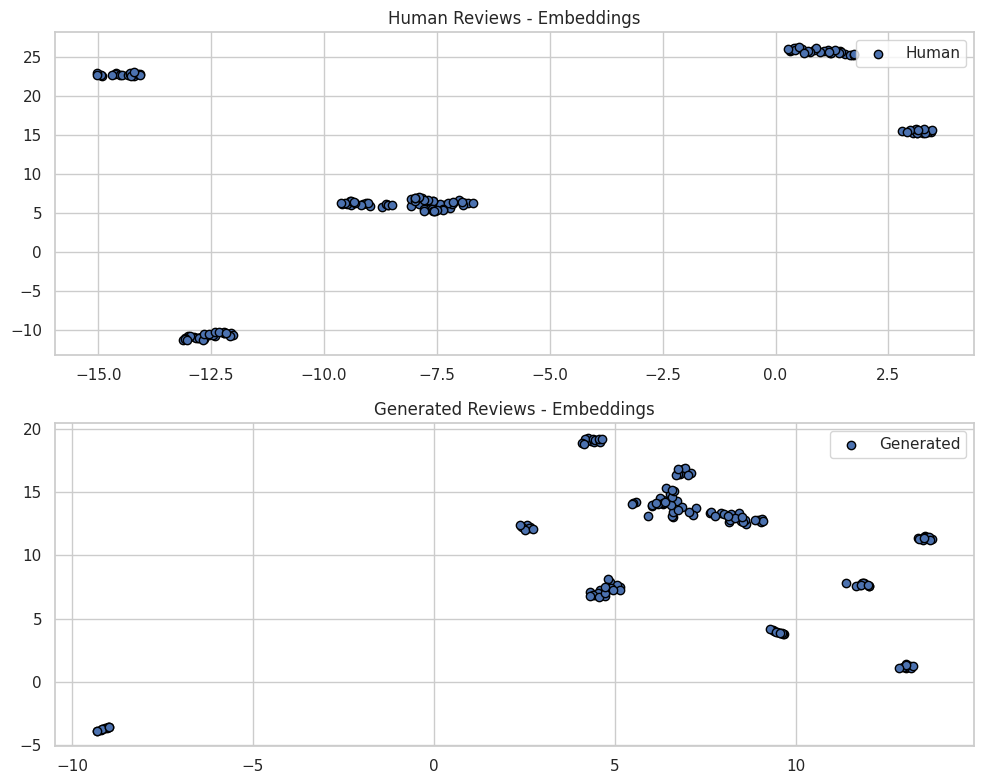

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.scatter(umap_embed_human[:, 0], umap_embed_human[:, 1], edgecolors='black', label="Human")
plt.title("Human Reviews - Embeddings")
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(umap_embed_gen[:, 0], umap_embed_gen[:, 1], edgecolors='black', label="Generated")
plt.title("Generated Reviews - Embeddings")
plt.legend()
plt.tight_layout()
plt.show()

# Style Embedding Similarity

In [37]:
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

style_model = AutoModel.from_pretrained("AnnaWegmann/Style-Embedding")
tokenizer = AutoTokenizer.from_pretrained("AnnaWegmann/Style-Embedding")

def get_style_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        emb = style_model(**inputs).last_hidden_state.mean(dim=1)
    return emb.squeeze().numpy()

results_df["style_human"] = results_df["human_review"].apply(get_style_embedding)
results_df["style_gen"] = results_df["gen_review"].apply(get_style_embedding)
results_df["style_sim"] = results_df.apply(lambda x: cosine_similarity(
    [x["style_human"]], [x["style_gen"]])[0][0], axis=1)

print("Average style similarity:", results_df["style_sim"].mean())

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/354 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Average style similarity: 0.92154884


# Per-Restaurant Aggregation

In [40]:
restaurant_summary = (
    results_df.groupby("restaurant")
      .agg({
          "cosine_sim": "mean",
          "semantic_similarity": "mean",
          "sentiment_diff": "mean"
      })
)
print(restaurant_summary.head())

                                cosine_sim  semantic_similarity  \
restaurant                                                        
3B's - Buddies, Bar & Barbecue    0.039891             0.452376   
Arena Eleven                      0.071064             0.394590   
Behrouz Biryani                   0.041515             0.189869   
Beyond Flavours                   0.068787             0.534290   
Deli 9 Bistro                     0.045516             0.548965   

                                sentiment_diff  
restaurant                                      
3B's - Buddies, Bar & Barbecue       -0.000822  
Arena Eleven                         -0.000048  
Behrouz Biryani                       0.000064  
Beyond Flavours                      -0.010271  
Deli 9 Bistro                        -1.797620  


# Per-Model Aggregation

In [41]:
model_summary = (
    results_df.groupby("model")
      .agg({
          "cosine_sim": "mean",
          "semantic_similarity": "mean",
          "sentiment_diff": "mean",
          "style_sim": "mean"
      })
)
print(model_summary.head())

                    cosine_sim  semantic_similarity  sentiment_diff  style_sim
model                                                                         
deepseek-r1:latest    0.048915             0.434424        0.211370   0.925612
llama3.1:latest       0.107682             0.483132       -0.148423   0.940043
mistral:latest        0.056415             0.427341       -0.281920   0.898992
qwen3:latest          0.097082             0.469264        0.000546   0.923288


## Aggregate similarities by restaurant to detect model-specific biases.

In [42]:
restaurant_model_summary = (
    results_df.groupby(["restaurant", "model"])
    .agg({
        "cosine_sim": "mean",
        "semantic_similarity": "mean",
        "style_sim": "mean",
        "sentiment_diff": "mean"
    })
)

print(restaurant_model_summary.head(10))

                                                                      cosine_sim  \
restaurant                                        model                            
3B's - Buddies, Bar & Barbecue                    mistral:latest        0.039891   
Arena Eleven                                      qwen3:latest          0.071064   
Behrouz Biryani                                   mistral:latest        0.041515   
Beyond Flavours                                   deepseek-r1:latest    0.068787   
Deli 9 Bistro                                     mistral:latest        0.045516   
Domino's Pizza                                    mistral:latest        0.091493   
Hitech Bawarchi Food Zone                         llama3.1:latest       0.130169   
Hotel Zara Hi-Fi                                  llama3.1:latest       0.098157   
Jonathan's Kitchen - Holiday Inn Express & Suites qwen3:latest          0.136329   
La La Land - Bar & Kitchen                        qwen3:latest          0.11

# LLM-based Content Detection

In [43]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

# Load detector model and tokenizer
detector_name = "roberta-base-openai-detector"
tokenizer = AutoTokenizer.from_pretrained(detector_name)
model = AutoModelForSequenceClassification.from_pretrained(detector_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [44]:
def detect_ai_generated(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = softmax(logits.numpy()[0])
    # Model output: index 0 = real, index 1 = fake (AI-generated)
    return {"real_prob": probs[0], "fake_prob": probs[1]}

### Detect AI Generated Text on Generated Reviews

In [45]:
results_df["detector_result_gen"] = results_df["gen_review"].apply(detect_ai_generated)
results_df["gen_real_prob"] = results_df["detector_result_gen"].apply(lambda x: x["real_prob"])
results_df["gen_fake_prob"] = results_df["detector_result_gen"].apply(lambda x: x["fake_prob"])

print(results_df[["gen_review", "gen_real_prob", "gen_fake_prob"]].head())

# compute mean fake probability
mean_fake_prob_gen = results_df["gen_fake_prob"].mean()
print(f"Average AI-detection probability (fake-generated): {mean_fake_prob_gen:.3f}")

                                          gen_review  gen_real_prob  \
0   used to love ominos for a quick pizza fix but...       0.000207   
1  ve always been a fan of talian cuisine so  app...       0.000170   
2   used to love ominos izza for its quick delive...       0.000169   
3  fter several years of enjoying the convenience...       0.000395   
4  eview itle isappointing xperience at ominos iz...       0.000251   

   gen_fake_prob  
0       0.999793  
1       0.999830  
2       0.999831  
3       0.999605  
4       0.999749  
Average AI-detection probability (fake-generated): 0.976


### Detect AI Generated Text on Human Reviews

In [46]:
results_df["detector_result_human"] = results_df["human_review"].apply(detect_ai_generated)
results_df["human_real_prob"] = results_df["detector_result_human"].apply(lambda x: x["real_prob"])
results_df["human_fake_prob"] = results_df["detector_result_human"].apply(lambda x: x["fake_prob"])

print(results_df[["human_review", "human_real_prob", "human_fake_prob"]].head())

# compute mean fake probability
mean_fake_prob_human = results_df["human_fake_prob"].mean()
print(f"Average AI-detection probability (fake-human): {mean_fake_prob_human:.3f}")

                                        human_review  human_real_prob  \
0  late an food is cold an bad delivery boys shd ...         0.040285   
1  late an food is cold an bad delivery boys shd ...         0.040285   
2  late an food is cold an bad delivery boys shd ...         0.040285   
3  late an food is cold an bad delivery boys shd ...         0.040285   
4  late an food is cold an bad delivery boys shd ...         0.040285   

   human_fake_prob  
0         0.959715  
1         0.959715  
2         0.959715  
3         0.959715  
4         0.959715  
Average AI-detection probability (fake-human): 0.775


# Per-Model Real/False Probability

In [47]:
model_prob = results_df.groupby("model").agg({"gen_fake_prob": "mean", "gen_real_prob": "mean"})
print(model_prob)

                    gen_fake_prob  gen_real_prob
model                                           
deepseek-r1:latest       0.935377       0.064623
llama3.1:latest          0.997375       0.002625
mistral:latest           0.999639       0.000361
qwen3:latest             0.918048       0.081952


In [50]:
real_prob_reviews = results_df[results_df['gen_real_prob'] > results_df['gen_fake_prob']][['model', 'gen_review', 'gen_real_prob',
                                                                                           'gen_fake_prob']]
real_prob_reviews

,model,gen_review,gen_real_prob,gen_fake_prob
55,qwen3:latest,a a and ar itchen feels like a place that sa...,0.568374,0.431626
62,deepseek-r1:latest,ouse he stars ozy intimate ambiance and warm a...,0.778979,0.221021
81,deepseek-r1:latest,ating eyond lavors eyond lavors might have ha...,0.975626,0.024374
98,deepseek-r1:latest,think the user meant detailed response should...,0.996642,0.003358


In [51]:
real_prob_reviews.gen_review.tolist()

['a a and  ar  itchen feels like a place that said it would deliver a vibrant bar food experience but the starter  orderedtuna tartare with avocadowas barely a snack tasting overly salty and lacking freshness he atmosphere was lively but the price for such a meager entry felt misleading ven the',
 'ouse he stars ozy intimate ambiance and warm almost like stepping into a hidden gem taff so sweet so helpful ushrooms creamy risotto was hit spot ust right ood ood fresh price nice',
 'ating  eyond lavors eyond lavors might have had okay food but dont get my patience just wait ishes expected ook ages long table way kept saying wrong order ood came back wrong dishes wrong aitress forgot explain much messed slow orse ood itself okay pricey sosoy not great essert made up it thoughworth hocolate cake divine ervice fast place recommend mbiance verall slow',
 ' think the user meant detailed response should be enthusiastic positive since4stars5stars aitcover taste atmosphere staff service pricing m

# Visualize The Results

## Model Performance Comparison

Create bar charts to compare `cosine_sim`, `semantic_similarity`, `style_sim`, and `sentiment_diff` across different models.


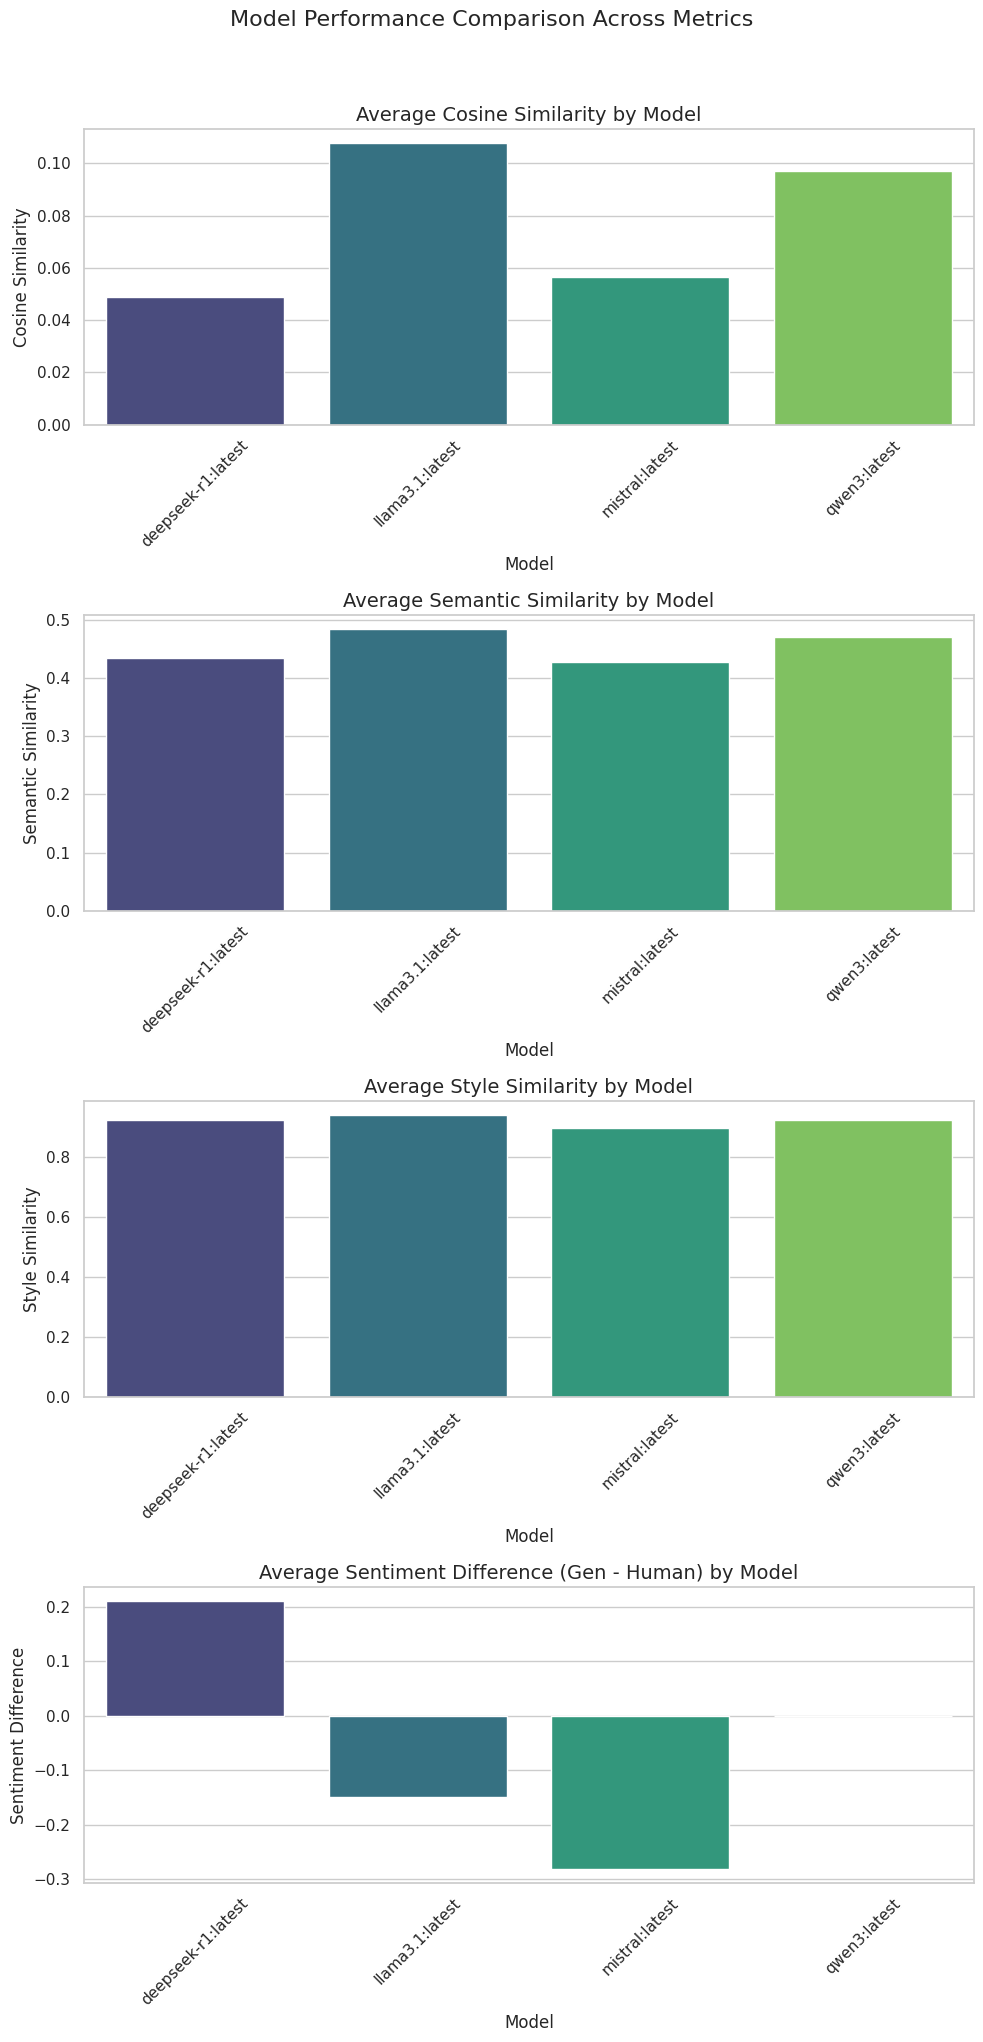

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Define the metrics to plot
metrics = ['cosine_sim', 'semantic_similarity', 'style_sim', 'sentiment_diff']
titles = {
    'cosine_sim': 'Average Cosine Similarity by Model',
    'semantic_similarity': 'Average Semantic Similarity by Model',
    'style_sim': 'Average Style Similarity by Model',
    'sentiment_diff': 'Average Sentiment Difference (Gen - Human) by Model'
}
ylabels = {
    'cosine_sim': 'Cosine Similarity',
    'semantic_similarity': 'Semantic Similarity',
    'style_sim': 'Style Similarity',
    'sentiment_diff': 'Sentiment Difference'
}

# Create subplots for each metric
fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 5 * len(metrics)))
fig.suptitle('Model Performance Comparison Across Metrics', fontsize=16, y=1.02)

for i, metric in enumerate(metrics):
    sns.barplot(x=model_summary.index, y=model_summary[metric], hue=model_summary.index, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(titles[metric], fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(ylabels[metric], fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The bar charts above visualize the average performance of each language model across several key metrics:

- **Average Cosine Similarity**: Measures the lexical overlap between generated and human reviews. A higher value indicates more similar wording.
- **Average Semantic Similarity**: Assesses the underlying meaning similarity between generated and human reviews, using BERT-based embeddings. Higher values suggest the generated reviews capture the essence of human reviews better.
- **Average Style Similarity**: Compares the stylistic resemblance between generated and human reviews. Higher values imply the generated text mimics the writing style of human reviews more closely.
- **Average Sentiment Difference (Gen - Human)**: Indicates the average difference in sentiment scores between generated and human reviews. Positive values mean generated reviews are more positive, while negative values mean they are more negative than human reviews.

### Average AI-Detection Probability by Model
Create a bar chart to show the average AI-detection probability (`gen_fake_prob`) for each model.


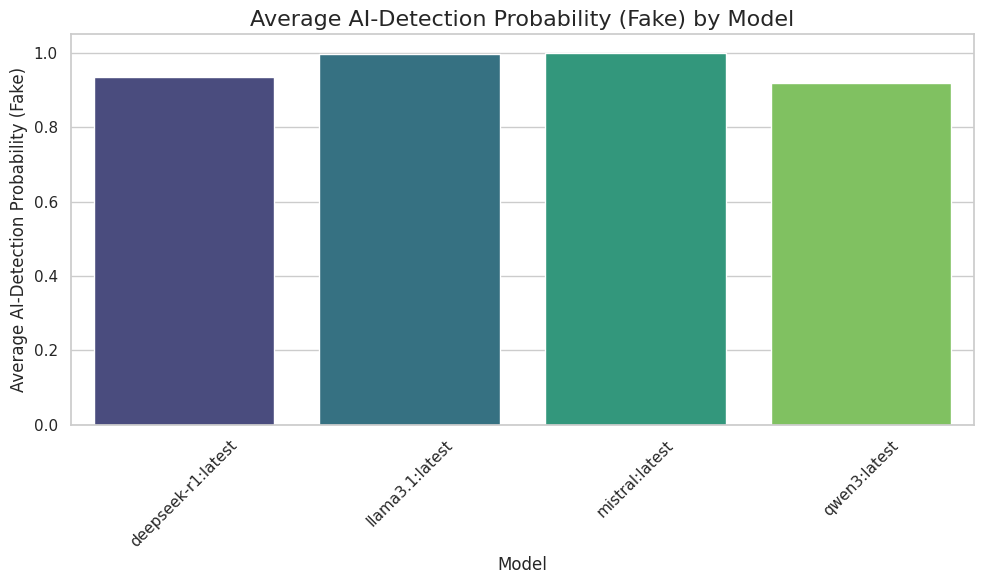

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(x=model_prob.index, y=model_prob['gen_fake_prob'], hue=model_prob.index, palette='viridis', legend=False)
plt.title('Average AI-Detection Probability (Fake) by Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average AI-Detection Probability (Fake)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Similarity Metrics
Create histograms to show the distribution of `cosine_sim` and `semantic_similarity`.

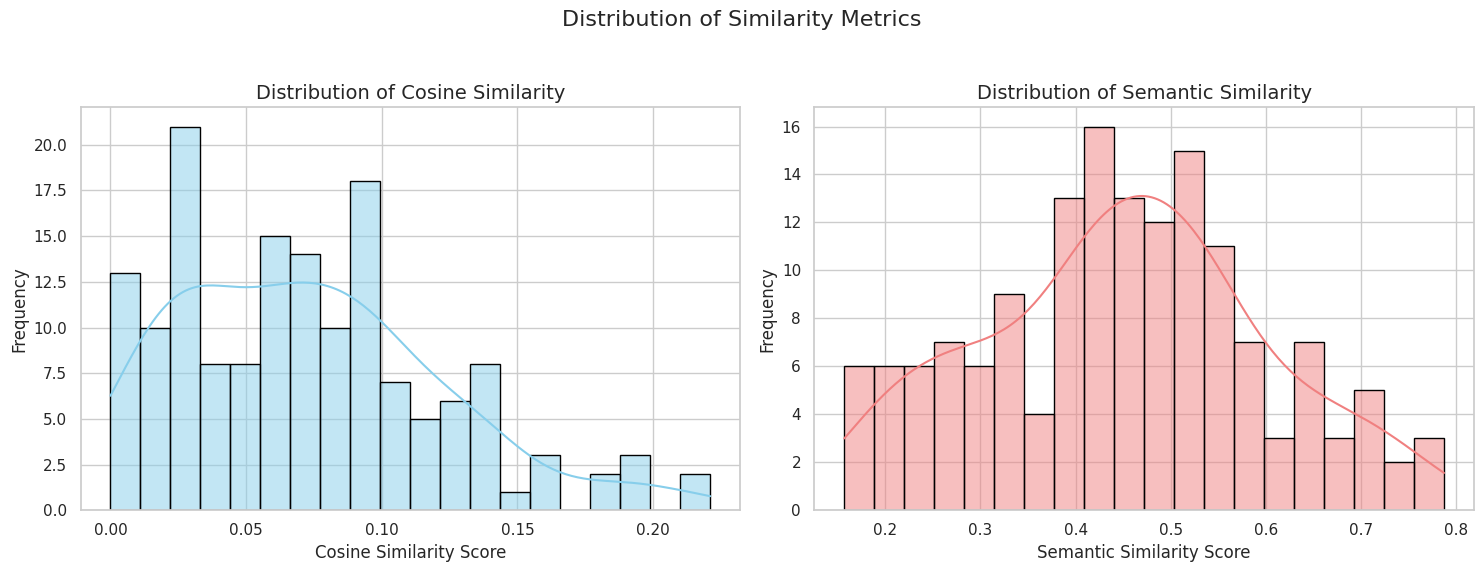

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribution of Similarity Metrics', fontsize=16)

# Histogram for Cosine Similarity
sns.histplot(results_df['cosine_sim'], bins=20, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Cosine Similarity', fontsize=14)
axes[0].set_xlabel('Cosine Similarity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Histogram for Semantic Similarity
sns.histplot(results_df['semantic_similarity'], bins=20, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Semantic Similarity', fontsize=14)
axes[1].set_xlabel('Semantic Similarity Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Compare Readability of Generated vs. Human Reviews
Create box plots to compare `readability_gen` and `readability_human` from `results_df`.

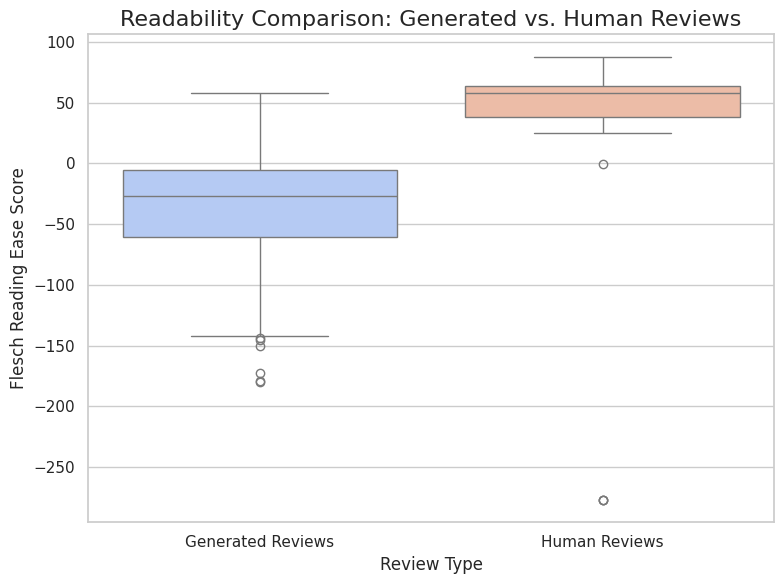

In [69]:
# Prepare data for box plot
readability_data = results_df[['readability_gen', 'readability_human']].melt(var_name='Review Type', value_name='Flesch Reading Ease Score')
readability_data['Review Type'] = readability_data['Review Type'].replace({
    'readability_gen': 'Generated Reviews',
    'readability_human': 'Human Reviews'
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Review Type', y='Flesch Reading Ease Score', data=readability_data, hue='Review Type', palette='coolwarm', legend=False)
plt.title('Readability Comparison: Generated vs. Human Reviews', fontsize=16)
plt.xlabel('Review Type', fontsize=12)
plt.ylabel('Flesch Reading Ease Score', fontsize=12)
plt.tight_layout()
plt.show()

### Compare AI-Detection Probability for Generated vs. Human Reviews
Create histograms to compare `gen_fake_prob` and `human_fake_prob` from `results_df`.

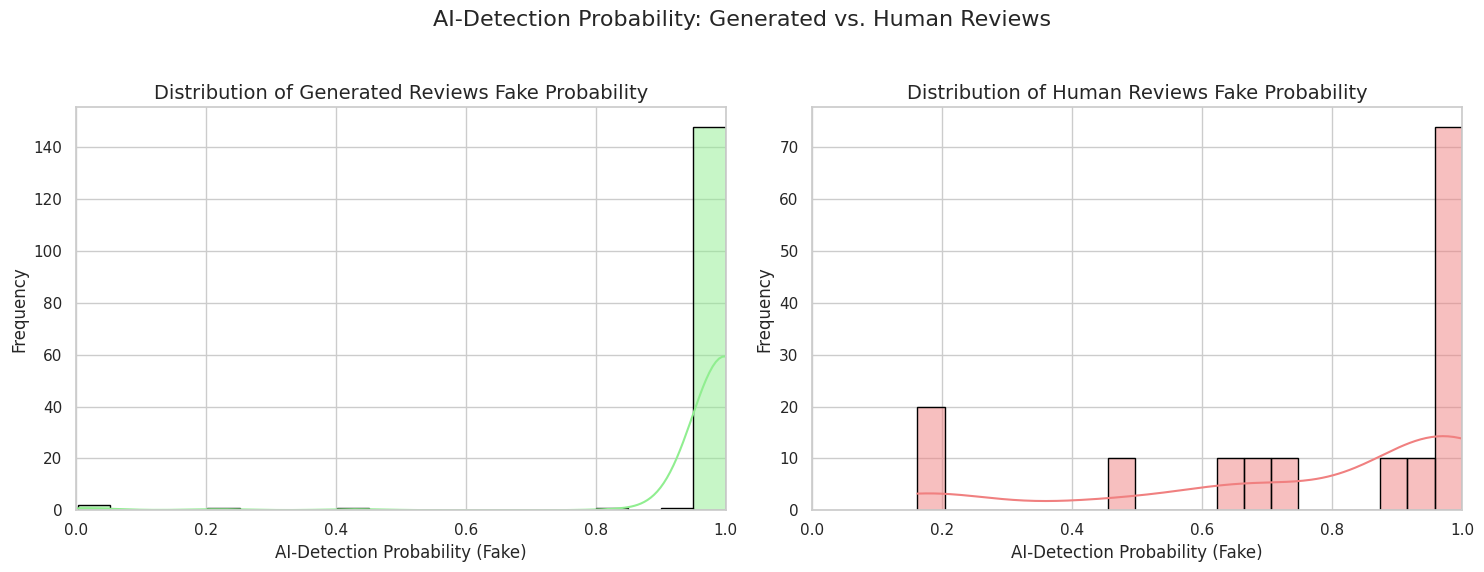

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AI-Detection Probability: Generated vs. Human Reviews', fontsize=16)

# Histogram for Generated Fake Probability
sns.histplot(results_df['gen_fake_prob'], bins=20, kde=True, ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Distribution of Generated Reviews Fake Probability', fontsize=14)
axes[0].set_xlabel('AI-Detection Probability (Fake)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xlim(0, 1) # Probability range

# Histogram for Human Fake Probability
sns.histplot(results_df['human_fake_prob'], bins=20, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Human Reviews Fake Probability', fontsize=14)
axes[1].set_xlabel('AI-Detection Probability (Fake)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(0, 1) # Probability range

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Model Performance across Metrics:**
    *   Bar charts were generated to compare average `cosine_sim`, `semantic_similarity`, `style_sim`, and `sentiment_diff` across different models, illustrating their varied performance in lexical, semantic, and stylistic similarity, as well as sentiment alignment with human reviews.
*   **Average AI-Detection Probability:**
    *   A bar chart was created showing the average AI-detection probability (`gen_fake_prob`) for each model, indicating how likely generated reviews from each model are to be flagged as AI-generated.
*   **Distribution of Similarity Metrics:**
    *   Histograms revealed the distribution of `cosine_sim` and `semantic_similarity` across all generated reviews, providing insights into the overall range and frequency of these similarity scores.
*   **Correlation between Rating and Generated Sentiment:**
    *   A scatter plot with a regression line visualized the relationship between the `rating` of the original review and the `sentiment_gen` of the generated review, suggesting how well models align sentiment with star ratings.
*   **Readability Comparison:**
    *   Box plots compared the Flesch Reading Ease scores for `readability_gen` (generated reviews) and `readability_human` (human reviews), highlighting differences in readability levels.
*   **AI-Detection Probability for Generated vs. Human Reviews:**
    *   Histograms showcased the distribution of AI-detection probabilities for both `gen_fake_prob` and `human_fake_prob`, allowing for a direct comparison of how detectable AI-generated content is versus human-written content.
